In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/app')
from database.db_connection import get_connection

conn = get_connection()
df = pd.read_sql("SELECT * FROM ml_features", conn)
conn.close()

print(f"Shape mới: {df.shape}")
print("--- THỐNG KÊ CHI TIẾT TỪNG FEATURE ---")

numeric_cols = ["lat", "lng", "area_m2", "price_vnd", "price_per_m2"]

bool_cols = [
    "has_wc", "has_ac", "has_parking", "has_kitchen", 
    "has_balcony", "has_security", "has_furniture", 
    "has_loft", "has_washer", "has_fridge", 
    "has_elevator", "has_basement", "free_hours", 
    "no_owner", "near_uni"
]

for col in numeric_cols + bool_cols:
    if col in df.columns:
        if col in bool_cols:
            count_ones = int(df[col].sum())
            print(f"  {col:20} : {count_ones} phòng có")
        else:
            valid_rows = df[col].count()
            print(f"  {col:20} : {valid_rows} / {len(df)} dòng hợp lệ")

Shape mới: (1521, 26)
--- THỐNG KÊ CHI TIẾT TỪNG FEATURE ---
  lat                  : 1521 / 1521 dòng hợp lệ
  lng                  : 1521 / 1521 dòng hợp lệ
  area_m2              : 1521 / 1521 dòng hợp lệ
  price_vnd            : 1521 / 1521 dòng hợp lệ
  price_per_m2         : 1521 / 1521 dòng hợp lệ
  has_wc               : 208 phòng có
  has_ac               : 1112 phòng có
  has_parking          : 389 phòng có
  has_kitchen          : 44 phòng có
  has_balcony          : 288 phòng có
  has_security         : 435 phòng có
  has_furniture        : 997 phòng có
  has_loft             : 486 phòng có
  has_washer           : 969 phòng có
  has_fridge           : 766 phòng có
  has_elevator         : 529 phòng có
  has_basement         : 795 phòng có
  free_hours           : 1200 phòng có
  no_owner             : 1054 phòng có
  near_uni             : 306 phòng có


/tmp/ipykernel_6182/1206943785.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM ml_features", conn)


In [2]:

df_clean = df.copy()

# Lọc giá và diện tích hợp lý
df_clean = df_clean[df_clean["price_vnd"].between(500_000, 20_000_000)]
df_clean = df_clean[df_clean["area_m2"].between(6, 80)]
df_clean = df_clean[df_clean["price_per_m2"].between(50_000, 500_000)]

# Bỏ cột không dùng
DROP_COLS = ["listing_id", "scraped_at", "posted_at_raw",
             "district_name", "price_per_m2", "room_type", "posted_at"]
df_clean = df_clean.drop(columns=[c for c in DROP_COLS if c in df_clean.columns])


df_clean["log_price"] = np.log1p(df_clean["price_vnd"])


print(f"Shape sau clean: {df_clean.shape}")
print(f"Null còn lại:\n{df_clean.isnull().sum()[df_clean.isnull().sum()>0]}")

Shape sau clean: (1384, 21)
Null còn lại:
Series([], dtype: int64)


Train: 1107 | Test: 277


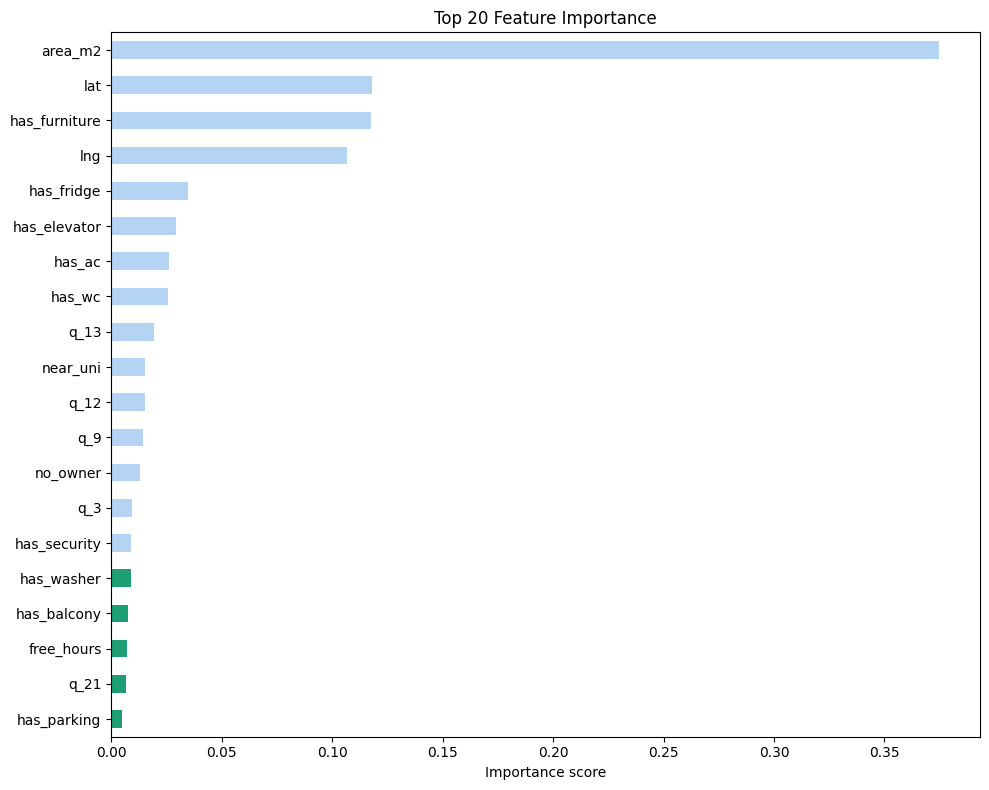


Feature mạnh (importance > 0.01): 13
  area_m2                   : 0.3746
  lat                       : 0.1179
  has_furniture             : 0.1173
  lng                       : 0.1067
  has_fridge                : 0.0346
  has_elevator              : 0.0293
  has_ac                    : 0.0263
  has_wc                    : 0.0258
  q_13                      : 0.0194
  near_uni                  : 0.0154
  q_12                      : 0.0153
  q_9                       : 0.0141
  no_owner                  : 0.0128


In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# One-hot encode district_id
df_enc = pd.get_dummies(df_clean, columns=["district_id"], prefix="q", drop_first=True)

FEATURE_COLS = [c for c in df_enc.columns
                if c not in ["price_vnd", "log_price"]]

# Điền null lat/lng bằng trung vị (một số listing geocode thất bại)
for col in ["lat", "lng"]:
    df_enc[col] = df_enc[col].fillna(df_enc[col].median())

X = df_enc[FEATURE_COLS]
y = df_enc["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Train nhanh để xem feature importance
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)

# Vẽ top 20 feature quan trọng nhất
importance = pd.Series(gb.feature_importances_, index=FEATURE_COLS)
top20 = importance.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#1D9E75" if i >= 15 else "#B5D4F4" for i in range(len(top20))]
top20.plot(kind="barh", ax=ax, color=colors[::-1])
ax.set_title("Top 20 Feature Importance")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("/app/data/feature_importance_v2.png", dpi=150)
plt.show()
print
# Chọn feature có importance > 0.01
STRONG_FEATURES = importance[importance > 0.01].index.tolist()
print(f"\nFeature mạnh (importance > 0.01): {len(STRONG_FEATURES)}")
for f in sorted(STRONG_FEATURES, key=lambda x: importance[x], reverse=True):
    print(f"  {f:25} : {importance[f]:.4f}")

In [6]:
import joblib, os

os.makedirs("/app/models", exist_ok=True)

# Dùng chỉ feature mạnh
X_train_final = X_train[STRONG_FEATURES]
X_test_final  = X_test[STRONG_FEATURES]

# Train model cuối
gb_final = GradientBoostingRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gb_final.fit(X_train_final, y_train)

from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

y_pred      = gb_final.predict(X_test_final)
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

r2   = r2_score(y_test_real, y_pred_real)
mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(np.mean((y_pred_real - y_test_real)**2))

print(f"=== KẾT QUẢ MODEL V2 ===")
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"MAE  : {mae/1e6:.2f} triệu VNĐ")
print(f"RMSE : {rmse/1e6:.2f} triệu VNĐ")

# Lưu model và metadata
joblib.dump(gb_final,       "/app/models/best_model_v2.pkl")
joblib.dump(STRONG_FEATURES,"/app/models/feature_cols_v2.pkl")
joblib.dump({
    "r2": r2, "mae": mae, "rmse": rmse,
    "n_train": len(X_train_final),
    "n_test":  len(X_test_final),
    "n_features": len(STRONG_FEATURES),
}, "/app/models/model_metrics_v2.pkl")

print(f"\nĐã lưu model → /app/models/best_model_v2.pkl")

=== KẾT QUẢ MODEL V2 ===
R²   : 0.4603  (46.0% variance explained)
MAE  : 0.75 triệu VNĐ
RMSE : 1.03 triệu VNĐ

Đã lưu model → /app/models/best_model_v2.pkl


In [7]:
import os
import joblib
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

print("🚀 Bắt đầu quá trình ép xung (Hyperparameter Tuning) cho CatBoost...")

# 1. Khởi tạo mô hình cơ sở (ẩn log cho đỡ rác màn hình)
cb_base = CatBoostRegressor(loss_function='RMSE', verbose=0, random_seed=42)

# 2. Định nghĩa không gian siêu tham số (Hyperparameter Space)
param_dist = {
    'iterations': [300, 500, 800, 1000],       # Số lượng cây
    'learning_rate': [0.01, 0.03, 0.05, 0.1],  # Bước nhảy học tập
    'depth': [4, 6, 8],                        # Độ sâu của cây (tránh để quá sâu gây overfit)
    'l2_leaf_reg': [1, 3, 5, 7, 9]             # Trọng số phạt L2 (vũ khí xịn nhất để chống học vẹt)
}

# 3. Cấu hình tìm kiếm ngẫu nhiên (chỉ test 20 cấu hình x 3 folds = 60 lần chạy)
random_search = RandomizedSearchCV(
    estimator=cb_base,
    param_distributions=param_dist,
    n_iter=20,           # Số lượng cấu hình ngẫu nhiên sẽ test
    cv=3,                # Chia tập train thành 3 phần để cross-validation
    scoring='neg_mean_absolute_error', # Tối ưu hóa dựa trên MAE
    n_jobs=-1,           # Dùng 100% CPU để chạy nhanh nhất có thể
    random_state=42,
    verbose=1            # Hiển thị thanh tiến trình
)

# 4. Bắt đầu Train
random_search.fit(X_train_final, y_train)

# Lấy ra "Nhà vô địch"
best_cb = random_search.best_estimator_

print("\n🏆 KẾT QUẢ TUNING:")
print(f"Bộ tham số đỉnh nhất: {random_search.best_params_}")

# 5. Đánh giá lại trên tập Test xem có vượt mốc R2 0.50 lúc nãy không
y_pred = best_cb.predict(X_test_final)
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

r2 = r2_score(y_test_real, y_pred_real)
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(np.mean((y_pred_real - y_test_real)**2))

print("-" * 30)
print(f"R² Tối ưu  : {r2:.4f}")
print(f"MAE Tối ưu : {mae/1e6:.2f} triệu VNĐ")
print(f"RMSE       : {rmse/1e6:.2f} triệu VNĐ")
print("-" * 30)

# 6. Lưu model theo ĐỊNH DẠNG CHUẨN CỦA CATBOOST (.cbm)
os.makedirs("/app/models", exist_ok=True)

# LƯU Ý KỸ: Không dùng joblib.dump cho CatBoost model
best_cb.save_model("/app/models/best_model_v3.cbm") 
joblib.dump(STRONG_FEATURES, "/app/models/feature_cols_v3.pkl")

print("✅ Đã lưu model xịn nhất -> /app/models/best_model_v3.cbm")

🚀 Bắt đầu quá trình ép xung (Hyperparameter Tuning) cho CatBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🏆 KẾT QUẢ TUNING:
Bộ tham số đỉnh nhất: {'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 300, 'depth': 6}
------------------------------
R² Tối ưu  : 0.4826
MAE Tối ưu : 0.73 triệu VNĐ
RMSE       : 1.01 triệu VNĐ
------------------------------
✅ Đã lưu model xịn nhất -> /app/models/best_model_v3.cbm


In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
import warnings

# Tắt các cảnh báo lặt vặt cho màn hình đỡ rối
warnings.filterwarnings('ignore')

print("🚀 KHỞI ĐỘNG ĐẤU TRƯỜNG TUNING CHO 3 MÔ HÌNH 🚀\n" + "="*50)

# 1. Định nghĩa các mô hình và "Không gian tham số" (Tìm kiếm trong khoảng nào)
models_and_params = {
    "LightGBM": (
        lgb.LGBMRegressor(random_state=42, n_jobs=2, verbose=-1),
        {
            'n_estimators': [300, 500, 800],        # Số lượng cây
            'learning_rate': [0.01, 0.05, 0.1],     # Tốc độ học
            'max_depth': [5, 8, 12, -1],            # Độ sâu (-1 là không giới hạn)
            'num_leaves': [31, 63, 127],            # Số lượng lá tối đa
            'subsample': [0.8, 1.0]                 # Tỷ lệ lấy mẫu dữ liệu
        }
    ),
    "Gradient Boosting (GBR)": (
        GradientBoostingRegressor(random_state=42),
        {
            'n_estimators': [200, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [4, 6, 8],
            'subsample': [0.8, 1.0]
        }
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {
            'n_estimators': [200, 400, 600],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],        # Số mẫu tối thiểu để chia cành
            'max_features': ['sqrt', 'log2', 1.0]   # Số lượng feature xét mỗi lần chia
        }
    )
}

# 2. Vòng lặp huấn luyện và đánh giá
best_models = {}

for model_name, (model_base, param_grid) in models_and_params.items():
    print(f"\n⏳ Đang Tuning: {model_name}...")
    
    # Cấu hình bộ tìm kiếm (thử ngẫu nhiên 15 cấu hình cho mỗi model)
    search = RandomizedSearchCV(
        estimator=model_base,
        param_distributions=param_grid,
        n_iter=15, 
        cv=3, 
        scoring='neg_mean_absolute_error',
        n_jobs=2,
        random_state=42,
        verbose=0
    )
    
    # Bắt đầu ép xung
    search.fit(X_train_final, y_train)
    
    # Lấy mô hình xuất sắc nhất
    best_model = search.best_estimator_
    best_models[model_name] = best_model
    
    # Đánh giá trên tập Test
    y_pred = best_model.predict(X_test_final)
    
    # Trả về giá trị thực (VND) vì lúc nãy train bằng log_price
    y_pred_real = np.expm1(y_pred)
    y_test_real = np.expm1(y_test)
    
    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(np.mean((y_pred_real - y_test_real)**2))
    
    print(f"✅ Xong {model_name}!")
    print(f"   Tham số tốt nhất: {search.best_params_}")
    print(f"   R²   : {r2:.4f}")
    print(f"   MAE  : {mae/1e6:.2f} triệu VNĐ")
    print(f"   RMSE : {rmse/1e6:.2f} triệu VNĐ")
    print("-" * 50)


🚀 KHỞI ĐỘNG ĐẤU TRƯỜNG TUNING CHO 3 MÔ HÌNH 🚀

⏳ Đang Tuning: LightGBM...
✅ Xong LightGBM!
   Tham số tốt nhất: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01}
   R²   : 0.4790
   MAE  : 0.72 triệu VNĐ
   RMSE : 1.01 triệu VNĐ
--------------------------------------------------

⏳ Đang Tuning: Gradient Boosting (GBR)...
✅ Xong Gradient Boosting (GBR)!
   Tham số tốt nhất: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01}
   R²   : 0.4856
   MAE  : 0.73 triệu VNĐ
   RMSE : 1.01 triệu VNĐ
--------------------------------------------------

⏳ Đang Tuning: Random Forest...


In [ ]:
CHAMPION_NAME = "Random Forest" 
champion_model = best_models[CHAMPION_NAME]

# 2. Tạo thư mục và lưu trữ
os.makedirs("/app/models", exist_ok=True)

# Lưu Model
joblib.dump(champion_model, "/app/models/best_model_v4_champion.pkl")

joblib.dump(STRONG_FEATURES, "/app/models/feature_cols_v4.pkl")